In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
import numpy as np

import random
from typing import Tuple, List, Optional
import matplotlib.pyplot as plt
from datetime import datetime
import copy
import pandas as pd



import lightning as pl
from lightning.pytorch.loggers import WandbLogger
import wandb
import pprint

import monai
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from kornia.losses import total_variation
import kornia


from Models.model import MLP, initialize_siren_weights, SineLayer, ReLULayer
from Models.model_trainer import ModelTrainerModule


from Models.models import Siren, Finer

from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
# from Data.load_ixi import load_data, load_sensitivity_data, get_hf_observed_segmentations
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper, plot_8_images_2rows, plot_3_images_row
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images, plot_2_images
from LFSynth.ContrastModulation import ContrastModulation
from Data.load_ixi import get_hf_observed_segmentations as get_hf_observed_segmentations_ixi, load_sensitivity_data
from Data.load_ixi import load_data as load_ixi_data
from LFSynth.HF_ContrastEstimation import load_val_data, get_hf_observed_segmentations as get_hf_observed_segmentations_val


from Data.patchwise3D import RandomPointsDataset
from onnxruntime import InferenceSession
import onnx

Data functions

In [2]:
def download_artifacts(run_list):
    artifact_dir_list = []

    api = wandb.Api()
    # run_id = "tmc3i3eo" #change this every time
    entity = "pi58-sussex/"
    project = "hulfsynth/"
    for run_id in run_list:
        run = api.run(entity + project + run_id)
        logged_artifacts = run.logged_artifacts(10)
        # print(logged_artifacts[0].name, logged_artifacts[1].name, logged_artifacts(temp)) #check number of logged artifacts in this list. usually should return two
        model_version = logged_artifacts[0].name
        print("Model version: ", model_version)
        artifact = api.artifact(entity + project +  model_version)
        artifact_dir = artifact.download()
        artifact_dir_list.append(artifact_dir)
    return artifact_dir_list


def get_data(config):
    ixi_nums = ["102", "105", "127", "128", "130"]
    dataset_num = config["dataset_num"]
    sens_id = config["sens_id"]
    if dataset_num in ixi_nums:
        if(str(sens_id) !="-1"):
            print("Loading sesitivity data: ", sens_id)
            hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_sensitivity_data(config)
        else:
            print("Loading IXI data: ", dataset_num)
            hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_ixi_data(config)
        (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg) = get_hf_observed_segmentations_ixi(config["dataset_num"], config)
        config["slice"] = 175
    else:
        print("Loading val data: ", dataset_num)
        hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_val_data(target_type = 'ulf' , config = config)
        (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg) = get_hf_observed_segmentations_val(config)
        config["slice"] = 19
        config["slice"] = 11 if str(dataset_num) == '0011' else (24 if str(dataset_num) == '0015' else 19) #slice_num and dataset_num[11: 0011, 24: 0015, 19: others]

    return (hf_ground_truth, lf_gt, lf_gt_seg_dice, M), (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg)


def add_rician(size_lf, v=1e-3, s=1e-3):
    # v =8, s = 5
    '''
        Adding Rician Noise using the magnitude of a Bivariate Normal Distribution with non-zero mean
        Reference : https://en.wikipedia.org/wiki/Rice_distribution
    '''
    N = 1
    for i in (size_lf):
        N = N * i  #Num of samples
    noise = np.random.normal(scale=s, size=(N, 2)) + [[v,0]]
    noise = np.linalg.norm(noise, axis=1)
    return (noise.reshape(size_lf))

def contrast_modulation(pred_seg, pred_img, config):
    downsampled_points = config["downsampled_points"]
    M = config["M"]
    size_lf = config["size_lf"]
    pred_seg = torch.from_numpy(pred_seg)
    pred_img = torch.from_numpy(pred_img)
    # imgs_list = [(F.interpolate((pred_seg[i] * pred_img).permute(2,0,1).unsqueeze(0), scale_factor=0.5).squeeze(0).permute(1,2,0)) for i in range(pred_seg.shape[0])]
    imgs_list = [(F.interpolate((pred_seg[i] * pred_img).permute(2,0,1).unsqueeze(0), size=size_lf[:-1]).squeeze(0).permute(1,2,0)) for i in range(pred_seg.shape[0])]
    bg_img = (imgs_list[0]).reshape(size_lf)
    wm_img = (imgs_list[1]).reshape(size_lf) * M[0]
    gm_img = (imgs_list[2]).reshape(size_lf) * M[1]
    csf_img = (imgs_list[3]).reshape(size_lf) * M[2]

    lf_img = wm_img + gm_img + csf_img #+ bg_img
    rician_noise = torch.from_numpy(add_rician(lf_img.shape)) #adding rician noise
    mask = torch.where(lf_img>0 ,1.0, 0.0)
    lf_img += (rician_noise * mask) #adding noise only to foreground voxels
    return lf_img.numpy()

Baseline functions

In [3]:
def get_canny(config, img):
    #expected img shape: (H, W, D); returns (H, W, D)
    canny = kornia.filters.Canny()
    img = img[:,:,config["slice"]] #getting a 2D slice
    img_magnitude, img_canny = canny(img.unsqueeze(0).unsqueeze(0))
    return img_canny.squeeze(0).squeeze(0)

def get_interpolated(img, scale_factor=1, mode='bicubic'):
    # expected img_shape: (H, W, D)
    img = img.permute(2,0,1).unsqueeze(0) #shape: (B, D(actuall C), H, W) where D is treated as C
    trilinear = torch.nn.functional.interpolate(img, scale_factor=scale_factor, mode=mode, recompute_scale_factor=True)
    trilinear = trilinear.squeeze(0).permute(1,2,0) #shape: (H,W,D)
    return trilinear
    

class GridFitting():
    def __init__(self, device=None) -> None:
        if(device!=None):
            self.device = device
        else:
            self.device = get_device()
    def create_3d_coordinate_grid(self, depth, height, width, device='cpu'):
        """
        Create a 3D grid of coordinates for the entire volume
        
        Args:
            depth: Volume depth (Z dimension)
            height: Volume height (Y dimension)  
            width: Volume width (X dimension)
            device: torch device
        
        Returns:
            coords: (D, H, W, 3) tensor of coordinates in [-1, 1] range
                    coords[d, h, w] = [x, y, z] coordinate for voxel (d, h, w)
        """

        
        # Create voxel coordinates for each dimension
        z_coords = torch.linspace(0, depth - 1, depth, device=device)   # [0, D-1]
        y_coords = torch.linspace(0, height - 1, height, device=device) # [0, H-1]
        x_coords = torch.linspace(0, width - 1, width, device=device)   # [0, W-1]

        
        # Create 3D meshgrid
        # indexing='ij' means first index is Z, second is Y, third is X
        grid_z, grid_y, grid_x = torch.meshgrid(z_coords, y_coords, x_coords, indexing='ij')
        
        # Normalize to [0, 1]
        grid_x_norm = grid_x / (width - 1)
        grid_y_norm = grid_y / (height - 1)
        grid_z_norm = grid_z / (depth - 1)
        
        # Convert to grid_sample format [-1, 1]
        grid_x_gs = grid_x_norm * 2 - 1
        grid_y_gs = grid_y_norm * 2 - 1
        grid_z_gs = grid_z_norm * 2 - 1

    
        # Stack into (D, H, W, 3) where last dim is [x, y, z]
        # # CRITICAL: grid_sample expects [x, y, z] order!
        coords = torch.stack([grid_x_gs, grid_y_gs, grid_z_gs], dim=-1).to(self.device)
        
        return coords


    def sample_volume_at_coordinates(self, volume, coords):
        """
        Sample 3D volume at given coordinates using grid_sample
        
        Args:
            volume: (1, C, D, H, W) tensor - the volume to sample from
            coords: (D, H, W, 3) tensor - coordinates to sample at
        
        Returns:
            sampled: (1, C, D, H, W) tensor - sampled volume
        """
        
        # grid_sample expects grid shape: (N, D, H, W, 3)
        # We have (D, H, W, 3), so add batch dimension
        grid = coords.unsqueeze(0)  # (1, D, H, W, 3)
        
        
        sampled = F.grid_sample(
            volume,
            grid,
            mode='bilinear',  # Actually trilinear for 3D!
            padding_mode='border',
            align_corners=True
        )
        
        
        return sampled



    def fit(self, volume, volume_size=None):
        """
        input shape: (H, W, D)
        volume_size: (D, H, W)
        output shape: (H, W, D)
        """
        volume = volume.permute(2,0,1) #changing shape to (D, H, W)
        if(volume_size!= None):
            D, H, W = volume_size
        else:
            D, H, W = volume_size = volume.shape
        
        
        volume = volume.unsqueeze(0).unsqueeze(0) #changing shape to (N, C, D, H, W)
        coords = self.create_3d_coordinate_grid(D, H, W) #(1, D,H,W,3)
        
        reconstructed = self.sample_volume_at_coordinates(volume, coords)
        volume = volume.squeeze(0).squeeze(0).permute(1,2,0) #changing shape to (H, W, D)
        reconstructed = reconstructed.squeeze(0).squeeze(0).permute(1,2,0) #changing shape to (H, W, D)
        return reconstructed
voxelgrid = GridFitting()


Device =  cuda:0


Inference

In [4]:
from typing import Tuple
def get_session(model_loc):
    # model_loc = './artifacts/tmc3i3eo:v0/model.onnx'
    onnx_model = onnx.load(model_loc)
    onnx.checker.check_model(onnx_model)
    # print(onnx_model.graph.input)
    onnx_model.graph.input[0].type.tensor_type.shape.dim[0].ClearField('dim_value')
    onnx_model.graph.input[0].type.tensor_type.shape.dim[1].ClearField('dim_value')
    sess = InferenceSession(onnx_model.SerializeToString())
    return sess

def get_coords(resolution: Tuple[int, ...]):
    
    print("sampling at resolution: ", resolution)
    meshgrid = torch.meshgrid([torch.arange(0, i, device=device) for i in resolution], indexing='ij')
    coords = torch.stack(meshgrid, dim=-1)
    coords_norm = coords / torch.tensor(resolution, device=device) * 2 - 1
    coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
    coords_norm_ += (torch.randn_like(coords_norm_) * 0.001) #adding gaussian noise with std = 0.001
    return coords_norm_


def sample_at_resolution(sess, hf_ground_truth, config):
    """ Evaluate our INR on a grid of coordinates in order to obtain an image. """
    # sess = InferenceSession(onnx_model.SerializeToString())
    resolution = hf_ground_truth.shape
    predictions_, _, pred_seg_, _ = sess.run(None, {"onnx::MatMul_0" : (get_coords(resolution).cpu().numpy())})
    # predictions_, _, pred_seg_, _ = self.forward(ff_pos_enc(coords_norm_ + (torch.randn_like(coords_norm_) * 0.001))) #adding gaussian noise with std = 0.01    
    resolution_seg = list(resolution) + [pred_seg_.shape[-1]] #adding num_tissues to the resolution shape
    predictions_hf = predictions_.reshape(resolution)
    pred_seg_ = pred_seg_.reshape(resolution_seg)
    pred_seg = [pred_seg_[:,:,:,i].reshape(resolution) for i in range(pred_seg_.shape[-1])]
    pred_seg = np.stack(pred_seg, axis = 0)
    pred_lf = contrast_modulation(pred_seg, predictions_hf, config)
    return predictions_hf, pred_seg, pred_lf


Image Metrics

In [5]:
from Utils.utils import MSLC, piqe_score
from deepinv.loss.metric import LPIPS, HaarPSI
def image_metrics(config, obs_img, pred_img):
    #Expected shapes: 3D (H, W, D)
    middle_slices = 5
    slice_num = config["slice"]
    psnr_value = monai.metrics.PSNRMetric(max_val = 1.0) #expects shape: BCHWD
    ssim_value = monai.metrics.regression.SSIMMetric(spatial_dims=3, data_range=1.0) #expects shape: BCHWD
    lpips = LPIPS()
    haar = HaarPSI(norm_inputs="clip")
    mslc = MSLC()
    # piqe_score()
    psnr_ =  psnr_value(pred_img.unsqueeze(0).unsqueeze(0), obs_img.unsqueeze(0).unsqueeze(0))
    ssim_ =  ssim_value(pred_img.unsqueeze(0).unsqueeze(0), obs_img.unsqueeze(0).unsqueeze(0))
    lpips_ = lpips(pred_img.unsqueeze(0).permute(3,0,1,2)[slice_num-middle_slices:slice_num+middle_slices], obs_img.unsqueeze(0).permute(3,0,1,2)[slice_num-middle_slices:slice_num+middle_slices]).mean() #computing score for middle 10 slices
    haar_ = haar(pred_img.unsqueeze(0).permute(3,0,1,2)[slice_num-middle_slices:slice_num+middle_slices], obs_img.unsqueeze(0).permute(3,0,1,2)[slice_num-middle_slices:slice_num+middle_slices]).mean() #computing score for middle 10 slices

    mslc_ = torch.tensor([mslc(pred_img[:,:,i].cpu().numpy()) for i in range(slice_num-5, slice_num+5)]).mean() #computing MSLC scor for middle 6 slices
    piqe_ = torch.tensor([piqe_score(pred_img[:,:,i].cpu().numpy()) for i in range(slice_num-5, slice_num+5)]).mean() #computing PIQE scor for middle 10 slices
    return psnr_, haar_, ssim_, lpips_, mslc_, piqe_
# psnr_, haar_, ssim_, lpips_, mslc_, piqe_ = image_metrics(config, gt_image[:,:,:,0], final_img) #Test function

Run inference for a single model

In [ ]:
config = copy.deepcopy(default_config)
device = get_device()
config["dataset_num"] = "0011"
(hf_ground_truth, lf_gt, lf_gt_seg_dice, M), (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg) = get_data(config)

gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
gt_image = gt_image.to(torch.float32)
lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
lf_gt = lf_gt.to(torch.float32)
config["size"] = hf_ground_truth.shape
config["size_lf"] = lf_gt.shape[:-1]
config["M"] = M
hf_observed_seg_dice = torch.stack((bg_obs_seg, wm_obs_seg, gm_obs_seg, csf_obs_seg), dim=0).unsqueeze(0)
slice_num = config["slice"]
f_obs = plot_2_images(gt_image[:,:,slice_num],lf_gt[:,:,slice_num], title1 = "Observed HF", title2 = "(synthetic) Observed ULF", )

In [ ]:
device = get_device()
run_list = ['bitmq93z']
artifact_dir_list = download_artifacts(run_list)
model_loc = artifact_dir_list[0] + '/model.onnx'
inference_session = get_session(model_loc)
predictions, pred_seg, pred_lf = sample_at_resolution(inference_session, hf_ground_truth, config)
predictions, pred_seg, pred_lf = torch.from_numpy(predictions), torch.from_numpy(pred_seg), torch.from_numpy(pred_lf)
plt.imshow(predictions.reshape(hf_ground_truth.shape)[:,:,slice_num], cmap='gray')
plt.colorbar()
plt.show()

Segmentation Visualizations

In [ ]:
(wm_gt_seg, gm_gt_seg, csf_gt_seg, bg_gt_seg) = (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg)
images_gt = [bg_gt_seg[:,:,slice_num], wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num]]
titles = ['BG', 'WM', 'GM', 'CSF']
fig = plot_4_images(wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num], bg_gt_seg[:,:,slice_num], title1="WM", title2="GM", title3="csf", title4="bg")
fig.suptitle('HF observed segmentations')
fig.tight_layout()
plt.show()

In [ ]:
images_gt = [bg_gt_seg[:,:,slice_num], wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num]]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_seg[0,:,:,slice_num], pred_seg[1,:,:,slice_num], pred_seg[2,:,:,slice_num], pred_seg[3,:,:,slice_num]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='HF Segmentations ', row_labels=['observed' +' (slice: ' + str(slice_num) +')', 'predicted '+ '(slice: ' + str(slice_num) +')'], save_path=None, dpi=100)

In [ ]:
other_slice = slice_num + 1
images_gt = [bg_gt_seg[:,:,other_slice], wm_gt_seg[:,:,other_slice], gm_gt_seg[:,:,other_slice], csf_gt_seg[:,:,other_slice]]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_seg[0,:,:,other_slice], pred_seg[1,:,:,other_slice], pred_seg[2,:,:,other_slice], pred_seg[3,:,:,other_slice]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='Segmentations ', row_labels=['observed' +' (slice: ' + str(other_slice) +')', 'predicted'+ '(slice: ' + str(other_slice) +')'], save_path=None, dpi=100)

In [ ]:
final_img = (predictions * pred_seg[1]) + (predictions * pred_seg[2]) + (predictions * pred_seg[3]) #+ (predictions * pred_seg[0])
# plt.imshow(final_img[:,:,95], cmap='gray')

images = [norm(torch.from_numpy(hf_ground_truth))[:,:,slice_num] , (predictions)[:,:,slice_num], (final_img)[:,:,slice_num]]
# images2 = [norm(predictions * pred_seg[0])[:,:,slice_num] , norm((predictions * pred_seg[2]))[:,:,slice_num], norm((predictions * pred_seg[3]))[:,:,slice_num]]
titles = ['observed', 'predicted', 'predicted (weighted sum)']
plot_3_images_row(images, titles=titles, figsize=(12, 4), cmap='gray',  suptitle='High Field', save_path=None, dpi=100, show_colorbar=True)

Segmentation Scores

In [ ]:
dice_score = monai.metrics.DiceMetric()
dice2 = monai.metrics.GeneralizedDiceScore()
iou_score = monai.metrics.MeanIoU()
psnr_value = monai.metrics.PSNRMetric(max_val = 1.0) #expects shape: BCHWD
ssim_value = monai.metrics.regression.SSIMMetric(spatial_dims=3, data_range=1.0) #expects shape: BCHWD

hf_gt_seg = torch.from_numpy(np.stack((bg_gt_seg, wm_gt_seg, gm_gt_seg, csf_gt_seg), axis = 0))


print("Dice (mean): ", dice_score(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0)).mean())
print("Dice (generalized): ", dice2(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0).to(torch.float32)).mean())
print("IoU (mean): ", iou_score(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0)).mean())
print("\n \n Scores of predictions")
print('psnr (norm): ', psnr_value( torch.from_numpy(norm(predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim (norm): ', ssim_value( torch.from_numpy(norm(predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('psnr : ', psnr_value( torch.from_numpy((predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim : ', ssim_value( torch.from_numpy((predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))

Final Image (multiple views)

In [ ]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
# data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
data = final_img
dims = data.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice = data[:, 200, :]
axes[0].imshow(coronal_slice, cmap='gray')
axes[0].set_title("Coronal View")

axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice = data[75, :, :]
axes[1].imshow(sagittal_slice, cmap='gray')
axes[1].set_title("Sagittal View")

axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice_index = 175
axial_slice = data[:, :, axial_slice_index]
axes[2].imshow(axial_slice, cmap='gray')
axes[2].set_title("Axial View")

axes[2].set_aspect('equal')
axes[2].invert_yaxis()

plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.patches as mpatches

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
# data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
data1 = pred_seg[1]
data2 = pred_seg[2]
data3 = pred_seg[3]
dims = data1.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice1 = data1[:, coronal_slice_index, :].T
coronal_slice2 = data2[:, coronal_slice_index, :].T
coronal_slice3 = data3[:, coronal_slice_index, :].T




axes[0].imshow(coronal_slice1, cmap='Greens')
axes[0].imshow(coronal_slice2, cmap='Reds', alpha = 0.9 * coronal_slice2)
axes[0].imshow(coronal_slice3, cmap='Blues', alpha = 0.9 * coronal_slice3)
axes[0].set_title("Coronal View")

axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice1 = data1[sagittal_slice_index, :, :].T
sagittal_slice2 = data2[sagittal_slice_index, :, :].T
sagittal_slice3 = data3[sagittal_slice_index, :, :].T
axes[1].imshow(sagittal_slice1, cmap='Greens', alpha = 0.9 * sagittal_slice1)
axes[1].imshow(sagittal_slice2, cmap='Reds', alpha = 0.9 * sagittal_slice2)
axes[1].imshow(sagittal_slice3, cmap='Blues', alpha = 0.9 * sagittal_slice3)
axes[1].set_title("Sagittal View")

axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice1 = data1[:, :, axial_slice_index].T
axial_slice2 = data2[:, :, axial_slice_index].T
axial_slice3 = data3[:, :, axial_slice_index].T

axes[2].imshow(axial_slice1, cmap='Greens', alpha = 0.9 * axial_slice1)
axes[2].imshow(axial_slice2, cmap='Reds', alpha = 0.9 * axial_slice2)
axes[2].imshow(axial_slice3, cmap='Blues', alpha = 0.9 * axial_slice3)
axes[2].set_title("Axial View")

axes[2].set_aspect('equal')
axes[2].invert_yaxis()


fig.suptitle("Segmentations (pve)", color='blue')
green_patch = mpatches.Patch(color='green', alpha=0.9, label='CSF')
red_patch = mpatches.Patch(color='red', alpha=0.9, label='GM')
blue_patch = mpatches.Patch(color='blue', alpha=0.9, label='CSF')

fig.legend(handles=[red_patch, blue_patch, green_patch])#, loc='lower right')
# fig.legend(handles=[red_patch, blue_patch], loc='center', fontsize=12)


plt.tight_layout()
plt.show()

Plot all images in a row function

In [8]:
def plot_images_in_row(config, images_row1: List[np.ndarray], images_row2: List[np.ndarray], titles: Optional[List[str]] = None, sup_title: Optional=None , vmax_list:Optional=None, cmap: str = 'gray', figsize: tuple = (15, 8)):
    """
    Plots two lists of images in two rows using Matplotlib.

    Args:
        images_row1 (List[np.ndarray]): A list of NumPy arrays representing the images for row 1.
        images_row2 (List[np.ndarray]): A list of NumPy arrays representing the images for row 2.
        titles (Optional[List[str]]): An optional list of titles for each image. If provided, the length must match the total number of images.
        cmap (str): The colormap to use for displaying the images. Default is 'gray'.
        figsize (tuple): The overall size of the figure. Default is (15, 8).
    """
    num_images_row1 = len(images_row1)
    num_images_row2 = len(images_row2)
    images_row1 = [images_row1[i][:,:,config["slice"]] for i in range(len(images_row1))] #Making 3D -> 2D for plotting
    # 1. Input Validation
    if num_images_row1 != num_images_row2:
        raise ValueError(f"Both rows must have the same number of images. Row 1 has {num_images_row1}, Row 2 has {num_images_row2}.")
    
    num_images = num_images_row1
    total_images = num_images_row1 + num_images_row2
        
    # if titles is not None and len(titles) != total_images:
    #     raise ValueError(f"The number of titles ({len(titles)}) must match the total number of images ({total_images}).")

    # 2. Create the Figure and Subplots (2 rows, N columns)
    fig, axes = plt.subplots(2, num_images, figsize=figsize, squeeze=True)

    # 3. Plot Each Image in Row 1
    for i in range(num_images):
        ax = axes[0, i]
        img = images_row1[i]
        
        if(vmax_list):
            vmax = vmax_list[i]
            im = ax.imshow(img.T, cmap=cmap, vmax=vmax)
        else:
            im = ax.imshow(img.T, cmap=cmap)
        # fig.colorbar(im, orientation='vertical', shrink=0.1)
        
        # Apply title if available
        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
        
        # Remove axis ticks and labels for cleaner image display
        ax.axis('off')
        ax.invert_yaxis()

    # 4. Plot Each Image in Row 2
    for i in range(num_images):
        ax = axes[1, i]
        img = images_row2[i]
        
        if(vmax_list):
            vmax = vmax_list[num_images + i]
            im = ax.imshow(img.T, cmap=cmap, vmax=vmax)
        else:
            im = ax.imshow(img.T, cmap=cmap)
        # fig.colorbar(im, orientation='vertical', shrink=0.1)
        
        # if titles is not None: # Apply title if available
        #     ax.set_title(titles[num_images + i], fontsize=10)
        
        # Remove axis ticks and labels for cleaner image display
        ax.axis('off')
        ax.invert_yaxis()

    # Adjust layout to prevent titles and images from overlapping
    if(sup_title):
        fig.suptitle(sup_title)
    plt.tight_layout()
    # [ax.invert_yaxis() for ax in plt.gcf().axes]

    plt.show()
    return fig

Validation data results

In [ ]:
run_list = ['0qwrq6e3', '16uuuxjs', '58htu1t6', 'poyiert4', 'amn5k6wl']
dataset_list = ['0011', '0015', '0023', '0027', '0035']

artifact_dir_list = download_artifacts(run_list)
hf_obs_list = []
lf_obs_list = []

lf_obs_seg_list = []
hf_obs_seg_list = []

hf_pred_list = []
lf_pred_list = []

lf_pred_seg_list = []
hf_pred_seg_list = []

config_list = []
final_img_list = []


device = get_device()
for i in range(len(artifact_dir_list)):
    model_loc = artifact_dir_list[i] + '/model.onnx'
    config = copy.deepcopy(default_config)
    config["dataset_num"] = dataset_list[i]
    (hf_ground_truth, lf_gt, lf_gt_seg_dice, M), (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg) = get_data(config)
    gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
    gt_image = gt_image.to(torch.float32)
    lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
    lf_gt = lf_gt.to(torch.float32)
    config["size"] = hf_ground_truth.shape
    config["size_lf"] = lf_gt.shape[:-1]
    config["M"] = M
    hf_observed_seg_dice = torch.stack((bg_obs_seg, wm_obs_seg, gm_obs_seg, csf_obs_seg), dim=0).unsqueeze(0)
    slice_num = config["slice"]
    inference_session = get_session(model_loc)
    pred_hf, pred_hf_seg, pred_lf = sample_at_resolution(inference_session, hf_ground_truth, config)
    pred_hf, pred_hf_seg, pred_lf = torch.from_numpy(pred_hf), torch.from_numpy(pred_hf_seg), torch.from_numpy(pred_lf)  

    pred_lf_seg = [(F.interpolate(pred_hf_seg[i].permute(2,0,1).unsqueeze(0), size=lf_gt.shape[:-2]).squeeze(0)).permute(1,2,0).reshape(lf_gt_seg_dice.shape[2:]) for i in range(pred_hf_seg.shape[0])] #downsampling pred_seg
    pred_lf_seg = torch.stack(pred_lf_seg,axis = 0) # shape(4 *H_lf, *W_lf, *D)
    pred_hf_seg = [pred_hf_seg[i].reshape(config["size"]) for i in range(pred_hf_seg.shape[0])]
    pred_hf_seg = torch.stack(pred_hf_seg, axis=0)
    final_img = norm((pred_hf * pred_hf_seg[1]) + (pred_hf * pred_hf_seg[2]) + (pred_hf * pred_hf_seg[3]))

    hf_obs_list.append(gt_image[:,:,:,0])
    lf_obs_list.append(lf_gt[:,:,:,0])
    hf_obs_seg_list.append(hf_observed_seg_dice[0])
    lf_obs_seg_list.append(lf_gt_seg_dice[0])
    hf_pred_list.append(pred_hf.reshape(config["size"]))
    lf_pred_list.append(pred_lf.reshape(config["size_lf"]))
    hf_pred_seg_list.append(hf_observed_seg_dice[0])
    lf_pred_seg_list.append(lf_gt_seg_dice[0])
    final_img_list.append(final_img)
    config_list.append(config)
    

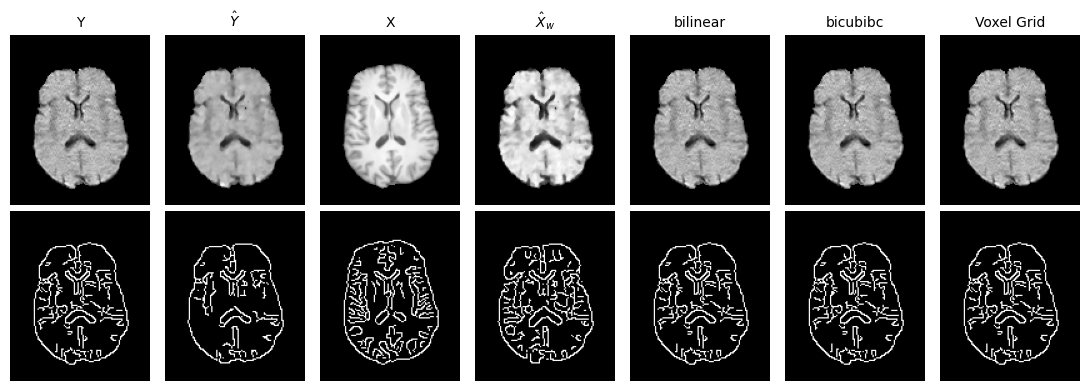

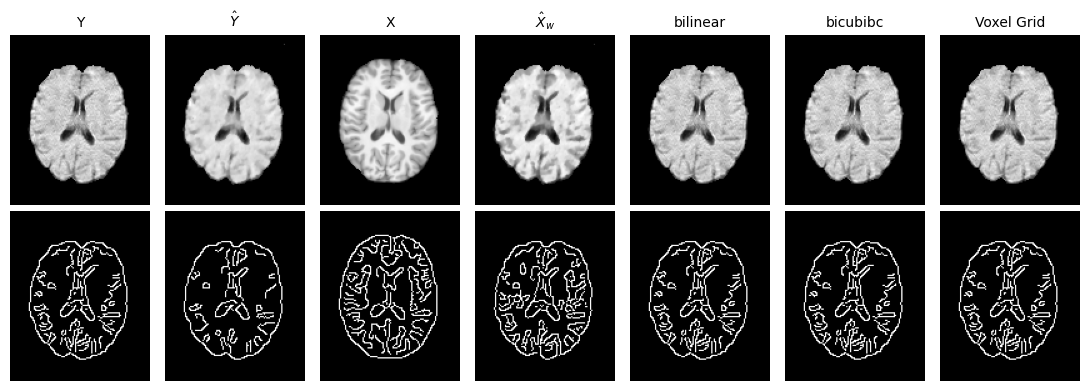

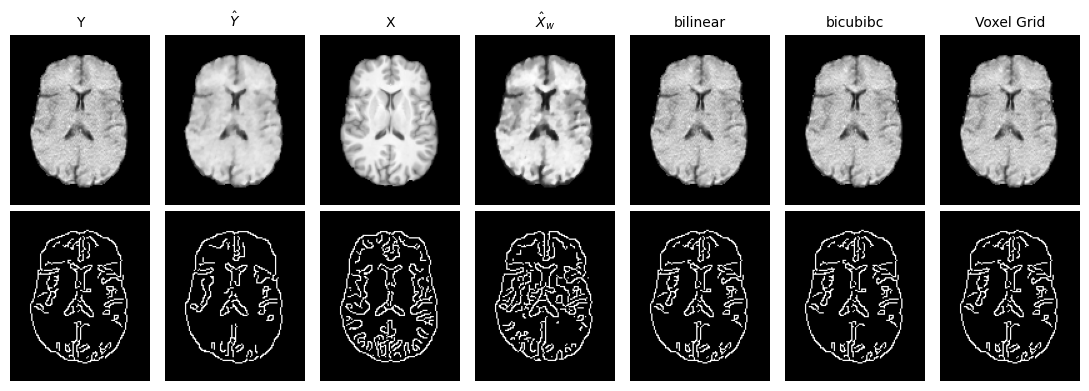

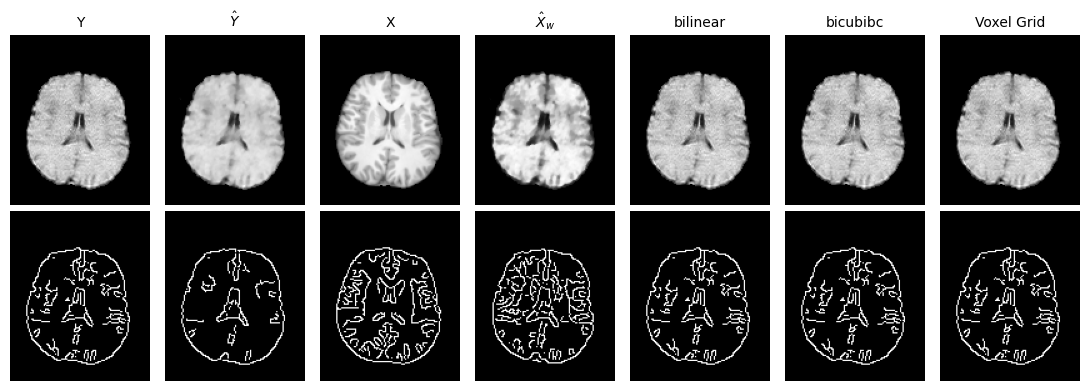

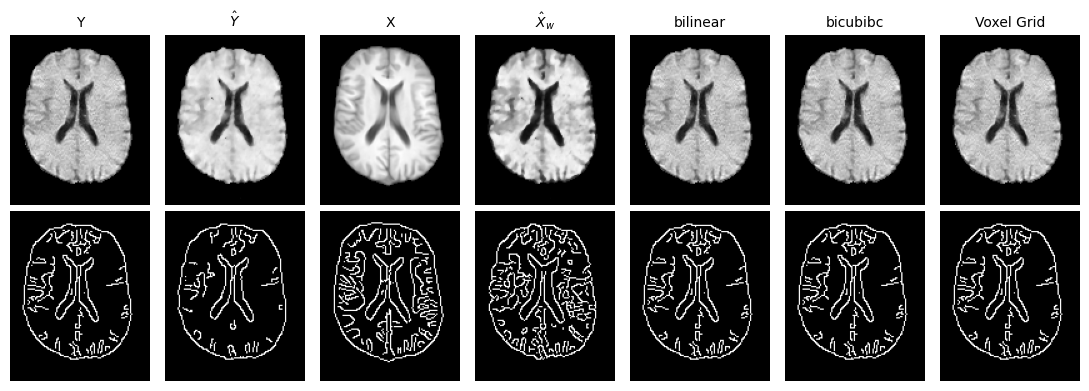

In [13]:

for i in range(len(dataset_list)):
    single_subject = [lf_obs_list[i], lf_pred_list[i], hf_obs_list[i], final_img_list[i]]
    interpolated = [get_interpolated(lf_obs_list[i], scale_factor=1, mode='bilinear') , get_interpolated(lf_obs_list[i], scale_factor=1, mode='bicubic'), voxelgrid.fit(lf_obs_list[i])]
    single_subject = single_subject + interpolated
    canny_subject = [get_canny(config_list[i], single_subject[j]) for j in range(len(single_subject))]
    titles = ["Y", "$\\hat{Y}$", "X", "$\\hat{X}_{w}$", "bilinear", "bicubibc", "Voxel Grid"] 
    fig = plot_images_in_row(config_list[i], single_subject, canny_subject, titles, cmap= 'gray', figsize=(11,4))
    fig.savefig('./val_results/' + dataset_list[i] + '.pdf')


In [17]:
subject_metrics = {"wire": [], "bilinear": [], "bicubic": [], "voxelgrid": []}
metrics_list = []
for i in range(len(dataset_list)):
    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], hf_pred_list[i])
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["wire"].append(metric_tuple)

    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], interpolated[0]) #bilinear
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["bilinear"].append(metric_tuple)

    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], interpolated[1]) #bicubic
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["bicubic"].append(metric_tuple)

    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], interpolated[2]) #voxelgrid
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["voxelgrid"].append(metric_tuple)

    metrics_list.append(subject_metrics)




Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa

In [59]:
def split_list_columns_v2(df):
    """Alternative method using apply"""
    result_dfs = []
    
    for col in df.columns:
        # Expand the list column
        expanded = df[col].apply(pd.Series)
        expanded.columns = [f"{col}_{i}" for i in range(len(expanded.columns))]
        result_dfs.append(expanded)
    
    return pd.concat(result_dfs, axis=1)

df = pd.DataFrame(subject_metrics)
validation_df = split_list_columns_v2(df)
new_names = ["psnr", "haar", "ssim", "lpips", "mslc", "piqe"]
validation_df.to_csv('./val_results/val_results.csv', index=False)

# mapping: 0:"psnr", 1: "haar", 2: "ssim", 3:"lpips", 4:"mslc", 5:"piqe"]
column_means = validation_df.mean()
# print(validation_df.head())
print(column_means)


wire_0          6.845019
wire_1          0.190678
wire_2          0.616051
wire_3          0.300147
wire_4          0.232294
wire_5         50.475921
bilinear_0     18.264660
bilinear_1      0.174808
bilinear_2      0.572937
bilinear_3      0.232570
bilinear_4      0.265935
bilinear_5     48.705559
bicubic_0      18.264660
bicubic_1       0.174808
bicubic_2       0.572937
bicubic_3       0.232570
bicubic_4       0.265935
bicubic_5      48.705559
voxelgrid_0    18.264661
voxelgrid_1     0.174808
voxelgrid_2     0.572937
voxelgrid_3     0.232570
voxelgrid_4     0.267153
voxelgrid_5    48.705711
dtype: float64


In [86]:
hf_obs_list = torch.tensor((), device=device)
lf_obs_list = torch.tensor((), device=device)

lf_obs_seg_list = torch.tensor((), device=device)
hf_obs_seg_list = torch.tensor((), device=device)

hf_pred_list = torch.tensor((), device=device)
lf_pred_list = torch.tensor((), device=device)

lf_pred_seg_list = torch.tensor((), device=device)
hf_pred_seg_list = torch.tensor((), device=device)

config_list = []
final_img_list = torch.tensor((), device=device)

torch.cuda.empty_cache()

Sensitivity results

In [6]:
device = get_device()
run_list = ['0ye4p313', 'yxi36ok6', '25gvh7d5', 'y9stwkw1', 'evp37xzg', 'a6imu6de', 'wvdtfihb', 'r8xf31s9'] # 1,2,3,4
# run_list = ['evp37xzg', 'a6imu6de', 'wvdtfihb', 'r8xf31s9'] #5, 6, 7, 8
dataset_list = ['102']
sens_id_list = [1, 2, 3, 4, 5, 6, 7, 8]
# sens_id_list = [5, 6, 7, 8]

artifact_dir_list = download_artifacts(run_list)
hf_obs_list = torch.tensor((), device=device)
lf_obs_list = torch.tensor((), device=device)

lf_obs_seg_list = torch.tensor((), device=device)
hf_obs_seg_list = torch.tensor((), device=device)

hf_pred_list = torch.tensor((), device=device)
lf_pred_list = torch.tensor((), device=device)

lf_pred_seg_list = torch.tensor((), device=device)
hf_pred_seg_list = torch.tensor((), device=device)

config_list = []
final_img_list = torch.tensor((), device=device)



for i in range(len(artifact_dir_list)):
    model_loc = artifact_dir_list[i] + '/model.onnx'
    config = copy.deepcopy(default_config)
    config["dataset_num"] = dataset_list[0] #only 102
    config["sens_id"] = i + 1 #i: 0 to 7 and sens_id: 1 to 8
    (hf_ground_truth, lf_gt, lf_gt_seg_dice, M), (wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg) = get_data(config)

    gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
    gt_image = gt_image.to(torch.float32).to(device)
    lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
    lf_gt = lf_gt.to(torch.float32).to(device)
    lf_gt_seg_dice = lf_gt_seg_dice.to(device)
    config["size"] = hf_ground_truth.shape
    config["size_lf"] = lf_gt.shape[:-1]
    config["M"] = M
    hf_observed_seg_dice = torch.stack((bg_obs_seg, wm_obs_seg, gm_obs_seg, csf_obs_seg), dim=0).unsqueeze(0).to(device)
    slice_num = config["slice"]
    inference_session = get_session(model_loc)
    pred_hf, pred_hf_seg, pred_lf = sample_at_resolution(inference_session, hf_ground_truth, config)
    pred_hf, pred_hf_seg, pred_lf = torch.from_numpy(pred_hf).to(device), torch.from_numpy(pred_hf_seg).to(device), torch.from_numpy(pred_lf).to(device)

    pred_lf_seg = [(F.interpolate(pred_hf_seg[i].permute(2,0,1).unsqueeze(0), size=lf_gt.shape[:-2]).squeeze(0)).permute(1,2,0).reshape(lf_gt_seg_dice.shape[2:]) for i in range(pred_hf_seg.shape[0])] #downsampling pred_seg
    pred_lf_seg = torch.stack(pred_lf_seg,axis = 0).to(device) # shape(4 *H_lf, *W_lf, *D)
    pred_hf_seg = [pred_hf_seg[i].reshape(config["size"]) for i in range(pred_hf_seg.shape[0])]
    pred_hf_seg = torch.stack(pred_hf_seg, axis=0).to(device)
    final_img = norm((pred_hf * pred_hf_seg[1]) + (pred_hf * pred_hf_seg[2]) + (pred_hf * pred_hf_seg[3])).to(device)

    # hf_obs_list.append(gt_image[:,:,:,0])
    hf_obs_list = torch.cat((hf_obs_list, gt_image[:,:,:,0].unsqueeze(0)), 0)
    # lf_obs_list.append(lf_gt[:,:,:,0])
    lf_obs_list = torch.cat((lf_obs_list, lf_gt[:,:,:,0].unsqueeze(0)), 0)
    # hf_obs_seg_list.append(hf_observed_seg_dice[0])
    hf_obs_seg_list = torch.cat((hf_obs_seg_list, hf_observed_seg_dice[0].unsqueeze(0)), 0)
    # lf_obs_seg_list.append(lf_gt_seg_dice[0])
    lf_obs_seg_list = torch.cat((lf_obs_seg_list, lf_gt_seg_dice[0].unsqueeze(0)), 0)
    # hf_pred_list.append(pred_hf.reshape(config["size"]))
    hf_pred_list = torch.cat((hf_pred_list, pred_hf.reshape(config["size"]).unsqueeze(0)), 0)
    # lf_pred_list.append(pred_lf.reshape(config["size_lf"]))
    lf_pred_list = torch.cat((lf_pred_list, pred_lf.reshape(config["size_lf"]).unsqueeze(0)), 0)
    # hf_pred_seg_list.append(hf_observed_seg_dice[0])
    hf_obs_seg_list = torch.cat((hf_obs_seg_list, hf_observed_seg_dice[0].unsqueeze(0)), 0)
    # lf_pred_seg_list.append(lf_gt_seg_dice[0])
    lf_obs_seg_list = torch.cat((lf_obs_seg_list, lf_gt_seg_dice[0].unsqueeze(0)), 0)

    hf_pred_seg_list = torch.cat((hf_pred_seg_list, pred_hf_seg.unsqueeze(0)), 0)
    lf_pred_seg_list = torch.cat((lf_pred_seg_list, pred_hf_seg.unsqueeze(0)), 0) #TODO: change this to LF segmet
    
    # final_img_list.append(final_img)
    final_img_list = torch.cat((final_img_list, final_img.unsqueeze(0)), 0)
    config_list.append(config)
    print(final_img_list.shape, hf_obs_seg_list.shape, hf_obs_list.shape)
    

Device =  cuda:0


Model version:  0ye4p313:v0


wandb:   1 of 1 files downloaded.  


Model version:  yxi36ok6:v0


wandb:   1 of 1 files downloaded.  


...

torch.Size([6, 150, 256, 256]) torch.Size([12, 4, 150, 256, 256]) torch.Size([6, 150, 256, 256])
Loading sesitivity data:  7
[0.2935365481740673, 0.34901972931303543, 0.4749207013501813]
sampling at resolution:  (150, 256, 256)


2025-10-22 13:26:15.923832478 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-22 13:26:15.950035386 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 116
2025-10-22 13:26:15.963044910 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-22 13:26:15.983972196 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 115


torch.Size([7, 150, 256, 256]) torch.Size([14, 4, 150, 256, 256]) torch.Size([7, 150, 256, 256])
Loading sesitivity data:  8
[0.22705385921479185, 0.23834161943960172, 0.19683175515958068]
sampling at resolution:  (150, 256, 256)


2025-10-22 13:27:00.803896134 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-22 13:27:00.812548296 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 116
2025-10-22 13:27:00.843880525 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-22 13:27:00.871838194 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 115


torch.Size([8, 150, 256, 256]) torch.Size([16, 4, 150, 256, 256]) torch.Size([8, 150, 256, 256])


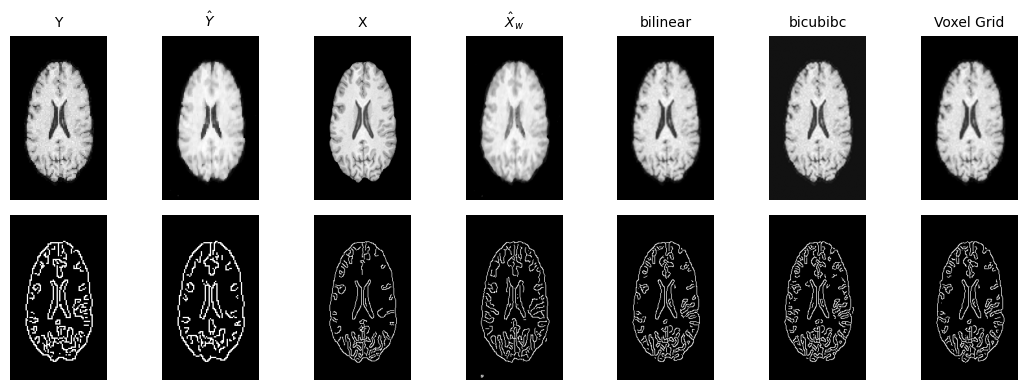

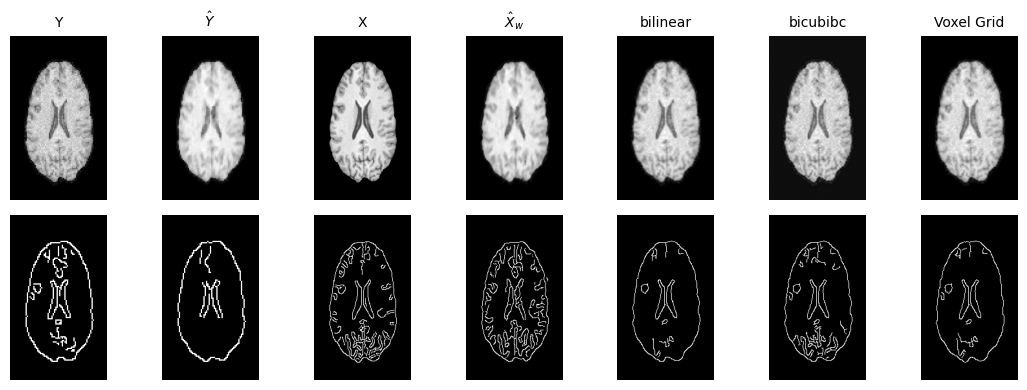

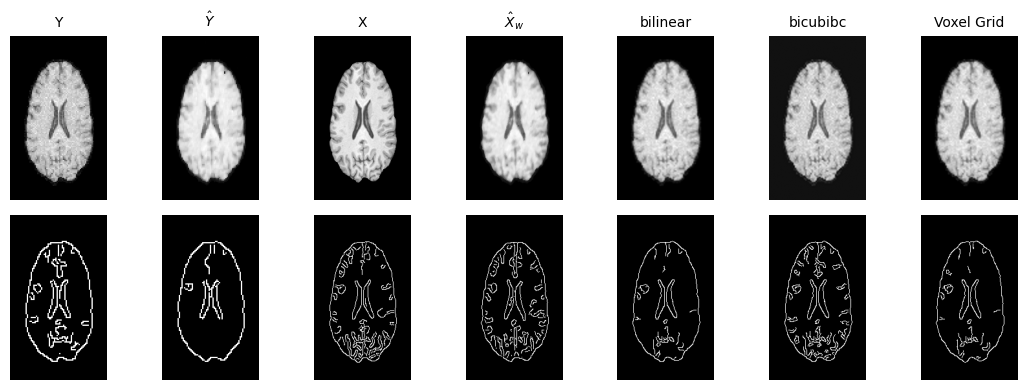

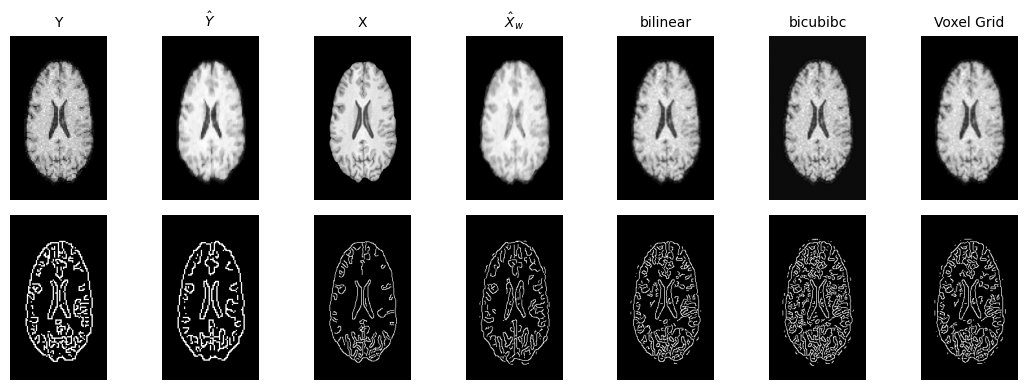

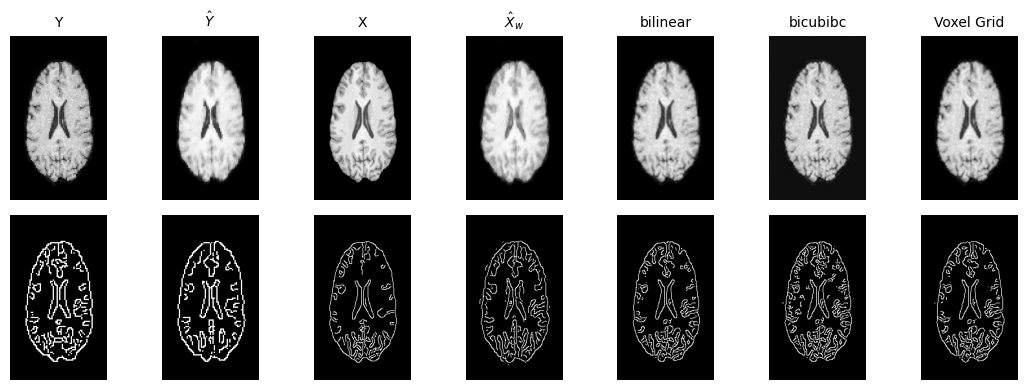

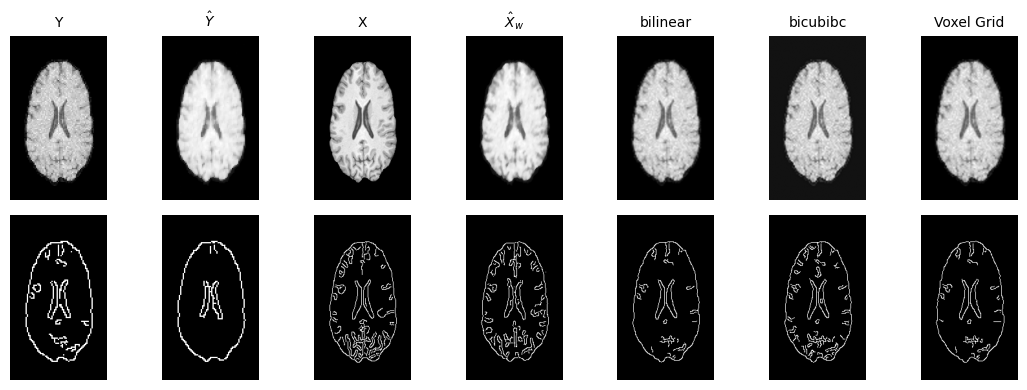

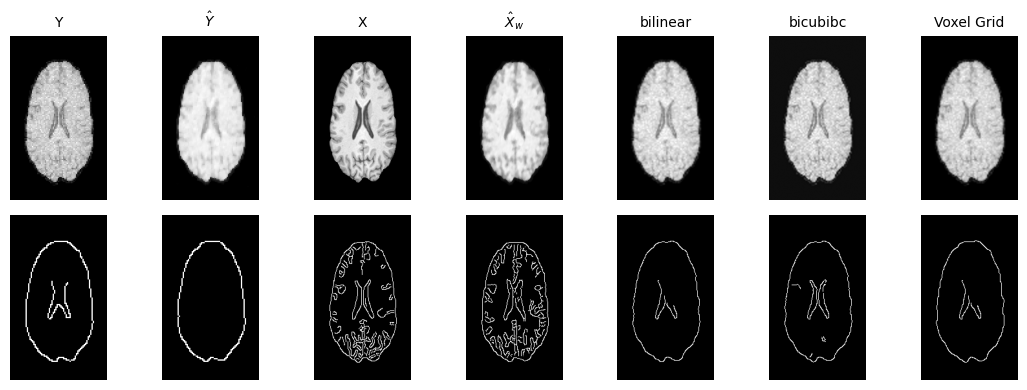

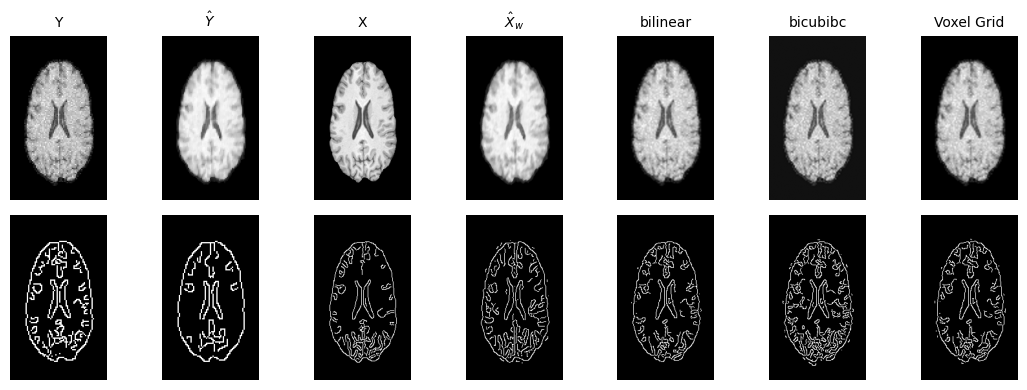

In [9]:
#plots
interpolated_list = []
for i in range(len(artifact_dir_list)):
    single_subject = [lf_obs_list[i], lf_pred_list[i], hf_obs_list[i], final_img_list[i]]
    interpolated = [get_interpolated(lf_obs_list[i], scale_factor=2, mode='bilinear') , get_interpolated(lf_obs_list[i], scale_factor=2, mode='bicubic'), voxelgrid.fit(lf_obs_list[i], volume_size=(256, 150 , 256))]
    single_subject = single_subject + interpolated
    canny_subject = [get_canny(config_list[i], single_subject[j]) for j in range(len(single_subject))]
    interpolated_list.append(interpolated)
    
    titles = ["Y", "$\\hat{Y}$", "X", "$\\hat{X}_{w}$", "bilinear", "bicubibc", "Voxel Grid"] 
    single_subject = [img.cpu().numpy() for img in (single_subject)]
    canny_subject = [img.cpu().numpy() for img in (canny_subject)]
    fig = plot_images_in_row(config_list[i], single_subject, canny_subject, titles, cmap= 'gray', figsize=(11,4))
    # fig.savefig('./sensitivity_results/' + str(sens_id_list[i]) + '.pdf')


In [10]:
subject_metrics = {"wire": [], "bilinear": [], "bicubic": [], "voxelgrid": []}
for i in range(len(artifact_dir_list)):
    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], final_img_list[i])
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["wire"].append(metric_tuple)

    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], interpolated_list[i][0]) #bilinear
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["bilinear"].append(metric_tuple)

    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], interpolated_list[i][1]) #bicubic
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["bicubic"].append(metric_tuple)

    metric_tuple = [psnr_, haar_, ssim_, lpips_, mslc_, piqe_] = image_metrics(config_list[i], hf_obs_list[i], interpolated_list[i][2]) #voxelgrid
    metric_tuple = [metric_tuple[i].item() for i in range(len(metric_tuple))]
    subject_metrics["voxelgrid"].append(metric_tuple)





Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth
Loading pretrained model LPIPS from /its/home/pi58/.cache/torch/hub/pyiqa

In [12]:
def split_list_columns_v2(df):
    """Alternative method using apply"""
    result_dfs = []
    
    for col in df.columns:
        # Expand the list column
        expanded = df[col].apply(pd.Series)
        expanded.columns = [f"{col}_{i}" for i in range(len(expanded.columns))]
        result_dfs.append(expanded)
    
    return pd.concat(result_dfs, axis=1)

df = pd.DataFrame(subject_metrics)
sens_df = split_list_columns_v2(df)
new_names = ["psnr", "haar", "ssim", "lpips", "mslc", "piqe"]
sens_df.to_csv('./sensitivity_results/sens_results.csv', index=False)

# mapping: 0:"psnr", 1: "haar", 2: "ssim", 3:"lpips", 4:"mslc", 5:"piqe"]
column_means = sens_df.mean()
# print(validation_df.head())
print(column_means)
sens_df.to_excel('./sensitivity_results/sens_results.xlsx', index=False)


wire_0         14.368154
wire_1          0.254485
wire_2          0.813845
wire_3          0.198824
wire_4          0.302590
wire_5         65.751215
bilinear_0     26.368653
bilinear_1      0.385501
bilinear_2      0.891641
bilinear_3      0.142111
bilinear_4      0.404286
bilinear_5     51.677560
bicubic_0      26.185429
bicubic_1       0.387906
bicubic_2       0.887996
bicubic_3       0.153102
bicubic_4       0.361188
bicubic_5      37.586465
voxelgrid_0    26.155352
voxelgrid_1     0.349381
voxelgrid_2     0.886738
voxelgrid_3     0.133147
voxelgrid_4     0.404848
voxelgrid_5    50.224534
dtype: float64


In [ ]:
#Download all models
'''
import wandb
run = wandb.init()
artifact = run.use_artifact('pi58-sussex/hulfsynth/model:v257', type='model')
artifact_dir = artifact.download()
artifact = run.use_artifact('pi58-sussex/hulfsynth/model:v258', type='model')
artifact_dir = artifact.download()
'''

In [ ]:
lf_gt_list = []
for i in range(1,6):
    _, lf_gt, _, M = load_sensitivity_data(dataset_num, config, sens_id=i)
    print("ID: ", i, "M: ", M)
    lf_gt_list.append(lf_gt)

def plot_5_images(img1, img2, img3, img4, img5, title1="img1", title2="img2", title3="img3", title4="img4", title5="img5"):

    fig, axes = plt.subplots(1,5, figsize=(20,6))
    im1 = axes[0].imshow(img1, cmap = 'gray', vmax=0.8)
    im2 = axes[1].imshow(img2, cmap = 'gray', vmax=0.8)
    im3 = axes[2].imshow(img3, cmap = 'gray', vmax=0.8)
    im4 = axes[3].imshow(img4, cmap = 'gray', vmax=0.8)
    im5 = axes[4].imshow(img5, cmap = 'gray', vmax=0.8)
    # im6 = axes[4].imshow(img5, cmap='Reds' ,alpha= 0.9*(condition))
    shrink_val = 0.25
    fig.colorbar(im1, shrink = shrink_val)
    fig.colorbar(im2, shrink = shrink_val)
    fig.colorbar(im3, shrink = shrink_val)
    fig.colorbar(im4, shrink = shrink_val)
    fig.colorbar(im5, shrink = shrink_val)
    # fig.colorbar(im6, shrink = 0.4)

    axes[0].set_title(title1)
    axes[1].set_title(title2)
    axes[2].set_title(title3)
    axes[3].set_title(title4)
    axes[4].set_title(title5)
    [axes[i].set_axis_off() for i in range(5)]
    # plt.show(block=False)
    return fig

fig_sens = plot_5_images(lf_gt_list[0][:,:,slice_num], lf_gt_list[1][:,:,slice_num], lf_gt_list[2][:,:,slice_num], lf_gt_list[3][:,:,slice_num], lf_gt_list[4][:,:,slice_num], 
title1="c1", title2="c2", title3="c3", title4="c4", title5="c5")


In [ ]:
# model_list = ['sens_1.1.onnx', 'sens_2.1.onnx', 'sens_3.1.onnx', 'sens_4.1.onnx', 'sens_5.1.onnx']
run_list = ['x2nz09km', 'ys1gampd', 'ym1ni51n', 'gaqe7gk7', 'sxfln2vf', '3s2d3ts7', '3efebuv3', '3uc6sg7a']
model_list = [1,2,3,4,5,6,7,8]
pred_list = []
pred_lf_list = []
pred_seg_list = []
lf_gt_list = []
M_list = []
lf_gt_seg_dice_list = []

# model_loc = './artifacts/' + run_list[4] + ':v0/model.onnx'
for i in (model_list):
    print(i, run_list[i-1])
    model_loc = './artifacts/' + run_list[i-1] + ':v0/model.onnx'
    print(model_loc)
    inference_session = get_session(model_loc)
    pred, pred_seg, pred_lf = sample_at_resolution(inference_session)
    _, lf_gt, lf_gt_seg_dice, M = load_sensitivity_data(dataset_num, config, sens_id=i)
    pred_list.append(pred)
    pred_lf_list.append(pred_lf)
    pred_seg_list.append(pred_seg)
    lf_gt_list.append(lf_gt)
    lf_gt_seg_dice_list.append(lf_gt_seg_dice)
    M_list.append(M)
    print('Inference for model', model_list[i-1], 'complete')

In [ ]:
norm_pred_list = []
final_img_list = []
ulf_residual_list = []
pred_ulf_list = []
for i in range(8):
    norm_pred = norm(pred_list[i])
    final_img = (norm_pred * pred_seg_list[i][1]) + (norm_pred * pred_seg_list[i][2]) + (norm_pred * pred_seg_list[i][3]) #+ (temp_pred * pred_seg[3])
    pred_ulf = contrast_modulation(pred_seg, final_img, config) #try with pred_img, norm_pred
    residual = np.abs(pred_ulf - lf_gt_list[i])
    
    final_img_list.append(final_img)
    norm_pred_list.append(norm_pred)
    pred_ulf_list.append(pred_ulf)
    ulf_residual_list.append(residual)
    
final_img_list = torch.tensor(final_img_list)
norm_pred_list =  torch.tensor(norm_pred_list)
ulf_residual_list = torch.tensor(ulf_residual_list)
pred_ulf_list = torch.tensor(pred_ulf_list)

visualize final images

In [ ]:

def plot_images_in_row(images: List[np.ndarray], titles: Optional[List[str]] = None, sup_title: Optional=None , vmax_list:Optional=None, cmap: str = 'gray', figsize: tuple = (15, 4)):
    """
    Plots a list of images in a single row using Matplotlib.

    Args:
        images (List[np.ndarray]): A list of NumPy arrays representing the images.
                                   (e.g., [img1, img2, img3])
        titles (Optional[List[str]]): An optional list of titles for each image.
                                      If provided, the length must match the number of images.
        cmap (str): The colormap to use for displaying the images. Default is 'gray'.
        figsize (tuple): The overall size of the figure. Default is (15, 4).
    """
    num_images = len(images)
    
    # 1. Input Validation
    if not 1 <= num_images <= 5:
        print(f"Warning: This function is optimized for 1 to 5 images. Received {num_images}.")
        # Continue execution even if the limit is exceeded, but warn the user.
        
    if titles is not None and len(titles) != num_images:
        raise ValueError(f"The number of titles ({len(titles)}) must match the number of images ({num_images}).")

    # 2. Create the Figure and Subplots (1 row, N columns)
    # The `squeeze=False` ensures that `axes` is always a 2D array, even if num_images=1, 
    # making the indexing consistent.

    vmax = 1.0
    fig, axes = plt.subplots(1, num_images, figsize=figsize, squeeze=False)
    
    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    # 3. Plot Each Image
    for i in range(num_images):
        ax = axes[i]
        img = images[i]
        
        if(vmax_list):
            vmax = vmax_list[i]
        im = ax.imshow(img, cmap=cmap, vmax=vmax)
        fig.colorbar(im, orientation='vertical',shrink=0.75)

        
        # Apply title if available
        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
        
        # Remove axis ticks and labels for cleaner image display
        ax.axis('off')

    # Adjust layout to prevent titles and images from overlapping
    if(sup_title):
        fig.suptitle(sup_title)
    plt.tight_layout()
    plt.show()



In [ ]:
temp_list = [lf_gt_list[0][:,:,slice_num], lf_gt_list[1][:,:,slice_num], lf_gt_list[2][:,:,slice_num], lf_gt_list[3][:,:,slice_num], lf_gt_list[4][:,:,slice_num]]
plot_images_in_row(
    images=temp_list,
    titles=['1', '2', '3', '4', '5',],
    sup_title = "(synthetic) ULF observed",
    vmax_list = [0.75, 0.4, 0.4, 0.75, 0.75],
    cmap='gray',
    figsize=(16, 2) # Smaller figure size for fewer images
)

In [ ]:
# temp_list = [final_img_list[0][:,:,slice_num], final_img_list[1][:,:,slice_num], final_img_list[2][:,:,slice_num], final_img_list[3][:,:,slice_num], final_img_list[4][:,:,slice_num]]
temp_list = [pred_ulf_list[0][:,:,slice_num], pred_ulf_list[1][:,:,slice_num], pred_ulf_list[2][:,:,slice_num], pred_ulf_list[3][:,:,slice_num], pred_ulf_list[4][:,:,slice_num]]
plot_images_in_row(
    images=temp_list,
    titles=['1', '2', '3', '4', '5',],
    sup_title = "ULF predicted",
    vmax_list = [0.35, 0.4, 0.4, 0.5, 0.5],
    cmap='gray',
    figsize=(16, 2) # Smaller figure size for fewer images
)

In [ ]:
# temp_list = [final_img_list[0][:,:,slice_num], final_img_list[1][:,:,slice_num], final_img_list[2][:,:,slice_num], final_img_list[3][:,:,slice_num], final_img_list[4][:,:,slice_num]]
temp_list = [ulf_residual_list[0][:,:,slice_num], ulf_residual_list[1][:,:,slice_num], ulf_residual_list[2][:,:,slice_num], ulf_residual_list[3][:,:,slice_num], ulf_residual_list[4][:,:,slice_num]]
plot_images_in_row(
    images=temp_list,
    titles=['1', '2', '3', '4', '5',],
    sup_title = "ULF residual (abs)",
    vmax_list = [0.3, 0.275, 0.25, 0.3, 0.3],
    cmap='Blues',
    figsize=(16, 2) # Smaller figure size for fewer images
)

In [ ]:
(sigma_ulf_residual, mu_ulf_residual) = torch.std_mean(ulf_residual_list, dim =0)
f2 = plot_2_images(mu_ulf_residual[:,:,slice_num], (sigma_ulf_residual**2)[:,:, slice_num], title1='$\\mu$', title2='$\\sigma^2$')

In [ ]:
f4 = plot_2_images(ulf_residual_list[0][:,:,175], ulf_residual_list[1][:,:,175], title1='sens_id=1', title2='sens_id=2')
f5 = plot_2_images(ulf_residual_list[2][:,:,175], ulf_residual_list[3][:,:,175], title1='sens_id=3', title2='sens_id=4')

In [ ]:

def plot_two_lists_on_dual_axis(epochs, list_A,list_B):
    """
    Plots two separate lists (list_A and list_B) on a single figure
    using the left and right Y-axes, respectively.
    """
    # --- Data Lists ---
    # Assume we are tracking performance over 10 epochs or iterations.
    # epochs = np.arange(1, 7) 
    

    # --- Setup the Figure and Primary Axis (Left Y-Axis) ---
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Define colors
    color_A = 'tab:green' 
    color_B = 'tab:red' 

    # Shared X-axis label
    ax1.set_xlabel('Target Contrast (WM-GM)', fontsize=12)

    # --- Plot List A on the Left Y-Axis (ax1) ---
    ax1.set_ylabel('SSIM', color=color_A, fontsize=12)
    # Plotting List A against the common X-axis (epochs)
    line_A, = ax1.plot(epochs, list_A, color=color_A, marker='o', linestyle='-', label='SSIM (Left)')
    ax1.tick_params(axis='y', labelcolor=color_A)
    ax1.grid(True, linestyle='--', alpha=0.6) # Grid for the primary axis

    # --- Create the Secondary Axis (Right Y-Axis) ---
    # twinx() makes this new axis share the same X-axis as ax1
    ax2 = ax1.twinx()  
    
    # --- Plot List B on the Right Y-Axis (ax2) ---
    ax2.set_ylabel('LPIPS', color=color_B, fontsize=12) 
    # Plotting List B against the common X-axis (epochs)
    line_B, = ax2.plot(epochs, list_B, color=color_B, marker='s', linestyle='--', label='LPIPS (Right)')
    ax2.tick_params(axis='y', labelcolor=color_B)
    
    # --- Final Polish: Combining Legends ---
    # We collect the lines from both axes to show them in a single legend
    lines = [line_A, line_B]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center', frameon=False)

    plt.title('Sensitivity Analysis: Target Contrast')
    plt.tight_layout()
    return fig

fig = plot_two_lists_on_dual_axis(epochs, ssim_list, lpips_list)
fig.savefig('./saved_models/sens_wire2/sens_target_contrast.pdf')


Sensitivity Quantitative Results

In [ ]:
ssim_list = [0.79019, 0.8374, 0.83575, 0.79852, 0.83385, 0.82918]
lpips_list = [0.24, 0.175, 0.185, 0.232, 0.191, 0.177]
idx= [4,3,2,8,7,6]
c_list = [[19.591889626325028, 74.45619024020756, 54.86430061388253],
[13.309712111059078, 35.49778633247732, 22.18807422141824],
[10.62876390679262, 36.76892223997362, 26.140158333180995],
[12.08320064326, 38.80917554433573, 26.72597490107573],
[15.131863348522124, 57.951366902350586, 42.81950355382846],
[6.70, 29.92, 23.21], 
[5.6, 20.4, 14.8], 
[8, 25, 17]]

In [ ]:
idx= [4,3,2,8,7,6]
epochs= [c_list[idx[i]-1][1] for i in range(len(idx))]
epochs

In [ ]:
ssim_list = [0.79019, 0.8374, 0.83575, 0.79852, 0.83385, 0.82918]
lpips_list = [0.24, 0.175, 0.185, 0.232, 0.191, 0.177]

plot_two_lists_on_dual_axis(epochs, ssim_list, lpips_list)

Canny Edge Detection

In [ ]:
import kornia
canny = kornia.filters.Canny()

# blur the image
x_magnitude, x_canny = canny(gt_image[:,:,slice_num,0].unsqueeze(0).unsqueeze(0))
y_magnitude, y_canny = canny(lf_gt[:,:,slice_num,0].unsqueeze(0).unsqueeze(0))

x_magnitude, x_canny = x_magnitude.squeeze(0).squeeze(0), x_canny.squeeze(0).squeeze(0)
y_magnitude, y_canny = y_magnitude.squeeze(0).squeeze(0), y_canny.squeeze(0).squeeze(0)
# f1 = plot_2_images(gt_image[:,:,slice_num,0],x_canny )
f1 = plot_4_images(gt_image[:,:,slice_num,0],x_canny, lf_gt[:,:,slice_num,0], y_canny)

plt.show()

In [ ]:
y_magnitude, y_canny = canny(lf_gt[:,:,slice_num,0].unsqueeze(0).unsqueeze(0))
X_pred_mag, X_pred_canny = canny(torch.from_numpy(predictions)[:,:,slice_num].unsqueeze(0).unsqueeze(0))
X_pred_mag, X_pred_canny = X_pred_mag.squeeze(0).squeeze(0), X_pred_canny.squeeze(0).squeeze(0)
y_magnitude, y_canny = y_magnitude.squeeze(0).squeeze(0), y_canny.squeeze(0).squeeze(0)

final_img_mag, final_img_canny = canny(torch.from_numpy(final_img)[:,:,slice_num].unsqueeze(0).unsqueeze(0))
final_img_mag, final_img_canny = final_img_mag.squeeze(0).squeeze(0), final_img_canny.squeeze(0).squeeze(0)
f1 = plot_2_images(lf_gt[:,:,slice_num,0],y_canny )
f2 = plot_2_images(gt_image[:,:,slice_num,0],X_pred_canny )
f3 = plot_2_images(final_img[:,:,slice_num],final_img_canny )

Interpolators

In [ ]:
bicubic = torch.nn.functional.interpolate(lf_gt[:,:,slice_num,0].unsqueeze(0).unsqueeze(0), scale_factor=1, mode='bicubic', align_corners=None, recompute_scale_factor=True, antialias=False)
bilinear = torch.nn.functional.interpolate(lf_gt[:,:,slice_num,0].unsqueeze(0).unsqueeze(0), scale_factor=1, mode='bilinear', align_corners=None, recompute_scale_factor=True, antialias=False)

bicubic_mag, bicubic_canny = canny(bicubic)
bilinear_mag, bilinear_canny = canny(bilinear)


bicubic_mag, bicubic_canny = bicubic_mag.squeeze(0).squeeze(0), bicubic_canny.squeeze(0).squeeze(0)
bicubic_mag, bilinear_canny = bilinear_mag.squeeze(0).squeeze(0), bilinear_canny.squeeze(0).squeeze(0)





In [ ]:
f1 = plot_2_images(bicubic[0,0,:,:],bicubic_canny )
f2 = plot_2_images(bilinear[0,0,:,:],bilinear_canny )
f3 = plot_2_images(final_img[:,:,slice_num],final_img_canny )
plt.show()